In [4]:
# importamos librerias
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import os
os.chdir('/home/jerry/Documents/master/Master/Machine learning - PART IV/Data')

# dataframe

In [9]:
df = pd.read_csv('titanic-2.csv')
df.head()
#3 aqui vemos qu ehay columans q no aportan mucho como ticker, passenger id, el nomobre,...
df.drop(columns=['PassengerId', 'Name', 'Ticket'],inplace=True)
df.drop_duplicates(inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,NaN,S,Mr
1,1,1,female,38.0,1,0,71.2833,C85,C,Mrs
2,1,3,female,26.0,0,0,7.9250,NaN,S,Miss
3,1,1,female,35.0,1,0,53.1000,C123,S,Mrs
4,0,3,male,35.0,0,0,8.0500,NaN,S,Mr


In [11]:
df.shape

(790, 10)

In [12]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,790.000000,790.000000,681.000000,790.000000,790.000000,790.000000
mean,0.412658,2.244304,29.853774,0.530380,0.415190,34.686587
std,0.492624,0.854311,14.728781,1.018692,0.836295,52.015473
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,20.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.875000
75%,1.000000,3.000000,39.000000,1.000000,1.000000,34.286450
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.dtypes # vemos que pclas a pesar de ser numerico es categorico, y si lo emtemos en un modelo no pasaria nada sin embargo en title, no lo podemos meter, tendriamos que transormarlo en numero y no tendria sentido el orden, pero cuando lelgue el momento ya vermo.s oero se tiene que transformar a numeros. al igual q el gender.
# cabin genemos muchos nulos. vamos a verlos

Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin           str
Embarked        str
Title           str
dtype: object

## nulos

In [ ]:
## hulos
df.isnull().sum() # en age tenemos 109, mientras que en cabina tenemos 586
## borrar filas, no interesa mucho en el tema de edad porq son jmuhcos, pero tmpc queremos borrar la columna ya que puede influir mucho. tendriamos que usar una tecnica de imputacion
# sin embargo, la cabina, tenemos uchos datos faltantes y podria ser interesante que los q tienen cabina, pueden lelgar a tener mas prob de sobrevivir, con lo q tmpc la queremos borrar. por lo tanto podemos ahcer con la cabina hacer una variable dummy y decir si tiene  o no caboina.
# embarqued tenemos 2, q no sabemos muy bien q es. sin embargo son 2 de 790, con loq  estos si que podriamos borrarlos

Survived      0
Pclass        0
Sex           0
Age         109
SibSp         0
Parch         0
Fare          0
Cabin       586
Embarked      2
Title         0
dtype: int64

(788, 10)
(788, 10)


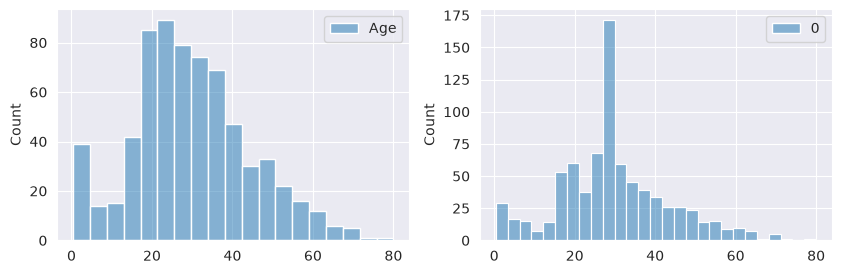

In [29]:
df2 = df.copy()
## todo loq  hacemos aqui se peude hacer scon un transofmrador de sklearn pero vamos a ahcerlo asi mejor
# cabin
df2['Cabin'] = df2['Cabin'].fillna(0)
df2['hasCabin'] = df2['Cabin'].apply(lambda x: 0 if x == 0 else 1)
df2.drop(columns=['Cabin'], inplace=True)
# embarked
# con estos dos nos lo vamos a cargar practivamnete
df2 = df2[~df2.Embarked.isnull()]

print(df2.shape)
df2.drop_duplicates(inplace=True)
print(df2.shape)

df2.head()

# ahora vemso sobre age
from sklearn.impute import SimpleImputer

x = df2[['Age']]
imputer1 = SimpleImputer(strategy='mean') # asi con media
x_new = imputer1.fit_transform(x)
x_new[:6]

# vamos a ahcerlo mejro con mediana
x = df2[['Age']]
imputer1 = SimpleImputer(strategy='median') # asi con mediana
x_new = imputer1.fit_transform(x)
x_new[:6]

# vemos graficamente
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
sns.histplot(x)
plt.subplot(1,2,2)
sns.histplot(x_new)
plt.show()

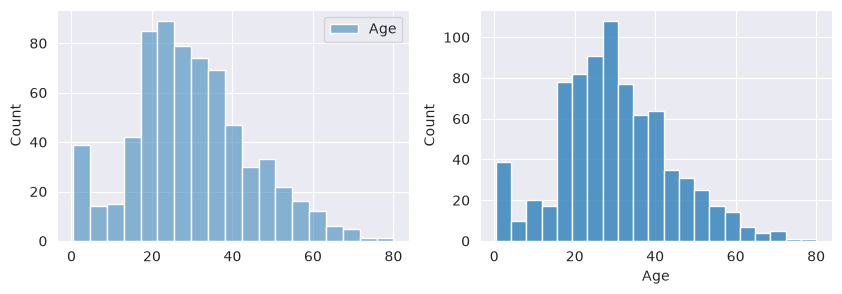

In [ ]:
# probamos con el knnimputer

from sklearn.impute import KNNImputer
# vamos a hacer q se fije segun lo q haya en ciertas variabels:
key_cols = ['Pclass','Age','SibSp','Parch','Fare']
x2 = df2[key_cols]
imputer2 = KNNImputer(n_neighbors=5, metric='nan_euclidean') # asi con media
x_new2 = imputer2.fit_transform(x2)
x_new2[:6] # nos ha puesto 25 , que han encontrado veciones cercanos con el q nos ha hecho los calculos para poner 25 

## vemos como queda graficaemnte
df2[key_cols] = x_new2

# vemos graficamente
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
sns.histplot(x)
plt.subplot(1,2,2)
sns.histplot(df2['Age'])
plt.show()

## parece ademas que queda super bien y limpio y se peude emeter en un pipeline y demas. cual es la desventaja? que todavia tiene mucho margen de mejora. igual nos interesa la media de edad de los q se han montado solo en chierburg,...

# ya sabemos que aqui podemos mejorar mucho mas pero tmpc es plan de quedarse parado aqui sino seguir adelante y poder tener el modelo cuanto antes y luego si sobra tiempo, mejorar eta feature

## Transformaciones

In [33]:
df3 = df2.copy()


cat_cols = [
    'Pclass', 'Sex', 'SibSp', 'Parch',
       'Embarked', 'Title', 'hasCabin'
]
num_cols = ['Age','Fare']

## CATEGORICAS

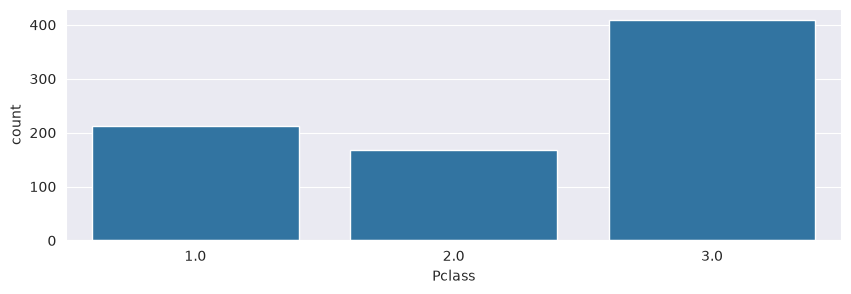

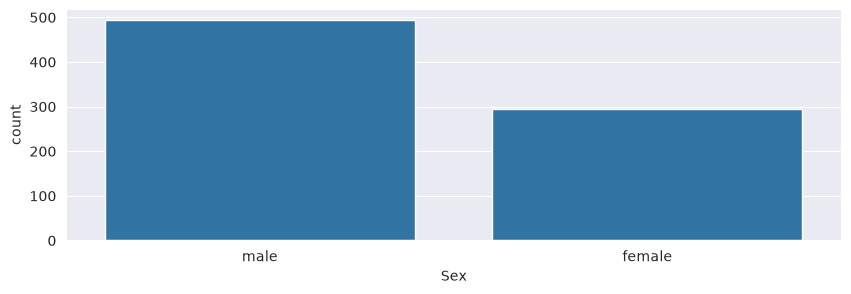

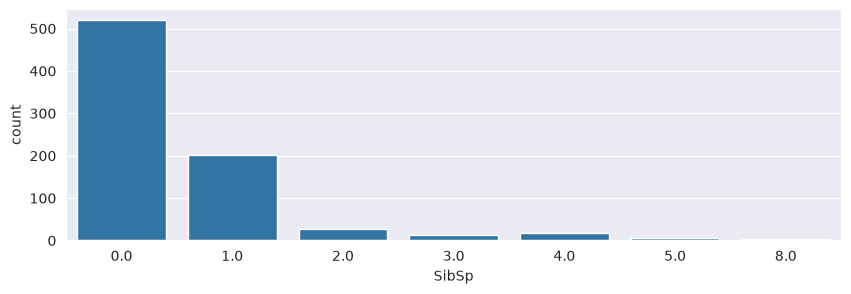

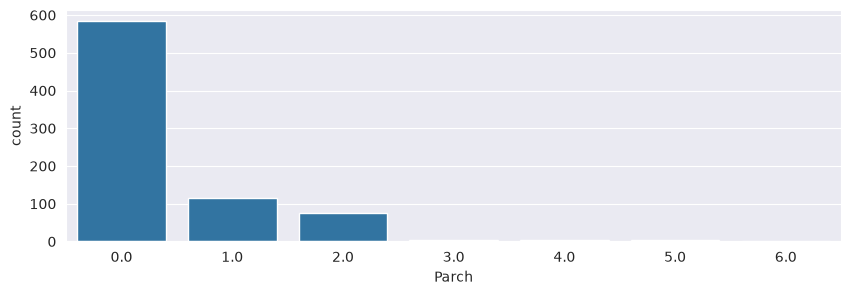

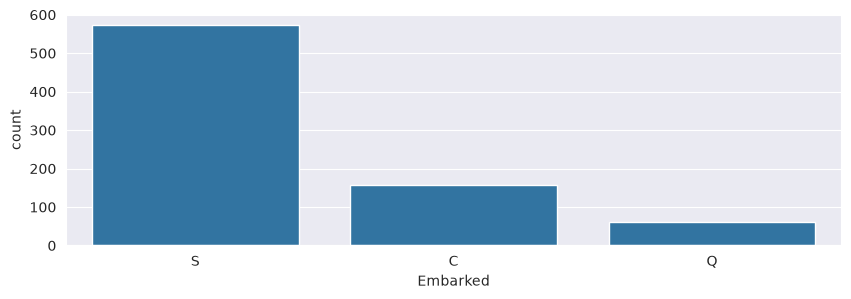

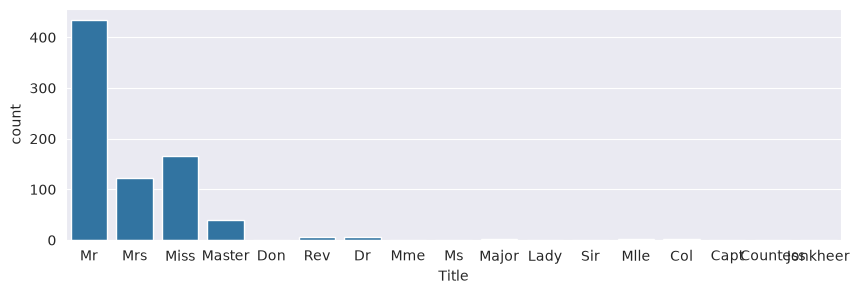

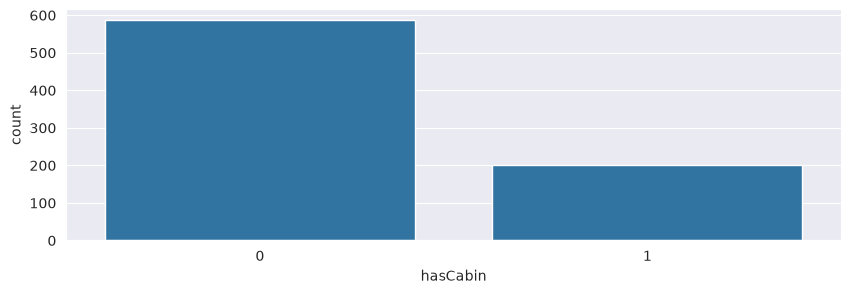

In [34]:
for col in cat_cols:
    plt.figure(figsize=(10,3))
    sns.countplot(data=df3,x=col)
    plt.show()

In [35]:
df3['SibSp'] = df3['SibSp'].apply(lambda x: 2 if x>=2 else x) ## esto se debe a que hay muy pocas q sean mayor q 2, por lo tanto las juntamos todas en la misma categoria porq noa fectaria mucho
df3['Parch'] = df3['Parch'].apply(lambda x: 2 if x>=2 else x) ## aqui pasa lo mismo que con sibsp
df3['Title'] = df3['Title'].apply(lambda x: x if x in['Mr','Mrs','Miss'] else 'otros') ## esto se debe a q de lo q mas hay es de estos 3 y los otros hay uy pocos, por lo tanto creamos una categoria con el resto de los otros

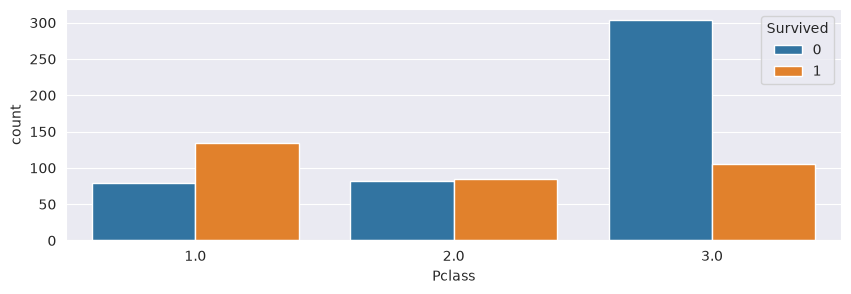

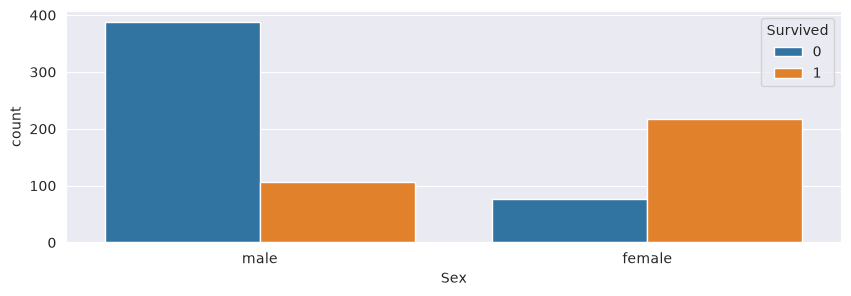

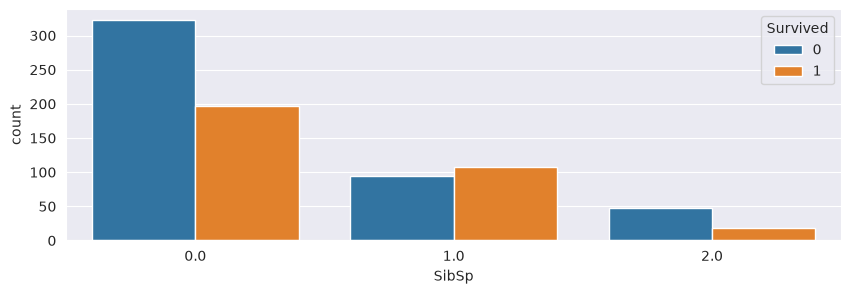

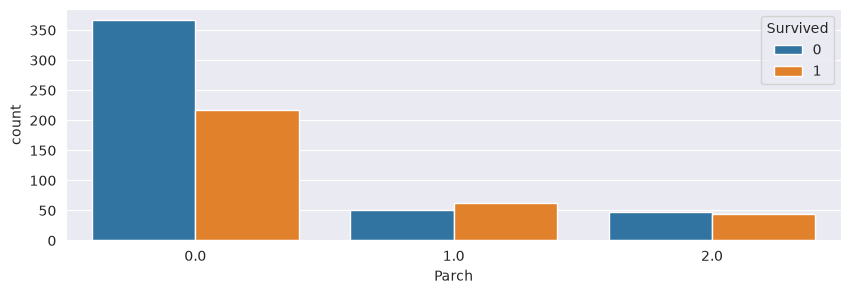

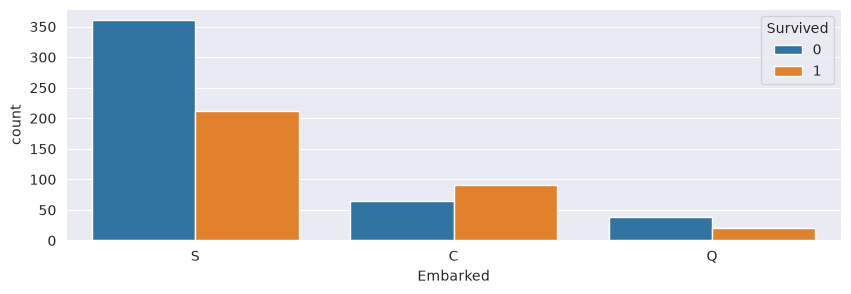

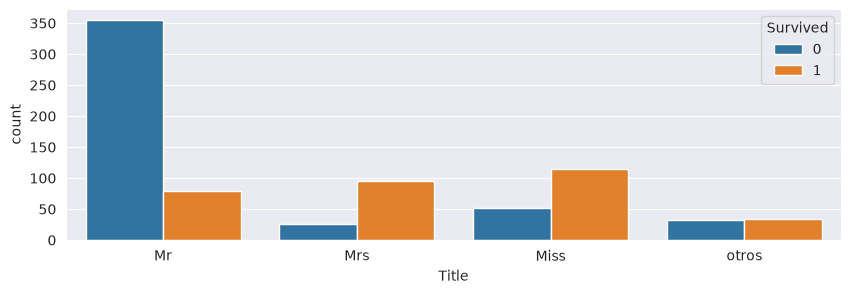

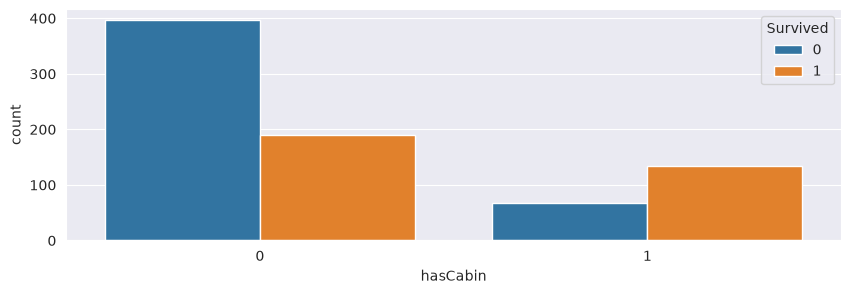

In [38]:
# verificamos q estan ya todos bien:
for col in cat_cols:
    plt.figure(figsize=(10,3))
    sns.countplot(data=df3,x=col,hue='Survived') # añadimos la variable target para ver bien si sobreviven o no
    plt.show()

In [68]:
# ohe
from sklearn.preprocessing import OneHotEncoder
df4 = df3.copy()

# sex
x = df4[['Sex']]
ohe_sex = OneHotEncoder(drop='if_binary') # el drop apra evitar que me de info de los dos al ser binarias
x_new = ohe_sex.fit_transform(x)

# embarked
x = df4[['Embarked']]
ohe_embarked = OneHotEncoder(drop='first') ## se carga solamente  la primera
x_new = ohe_embarked.fit_transform(x)

# # title
# en vez de con pandas, vamos a hacerlo con onegotencoder
titles=[['Mr','Mrs','Miss']]
x = df4[['Title']]
ohe_title = OneHotEncoder(categories=titles, handle_unknown='ignore') # cuando da error porq no entuenctara a otros, quiero que me ponga 0,0,0. para ello se usa la funcion de handle unknonw
x_new = ohe_title.fit_transform(x)

In [69]:
x[:8]

,Title
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
5,Mr
6,Mr
7,otros


In [ ]:
x_new[:8].toarray() # cuando es binaria la categoria, no tiene sentido meter las 2 clases a la vez. cuando es binaria es mejor quitar una entera
## cuando hay 3, se peuden meter al modelo tal cual las 3 o c tmb usar la estrategia de te paso solo 2. esto se hace con la estrategia de drop
## cuando hay 4 podemos hacer lo mismo, drop first, pero vamos a practicar otra cosa distinta

## loq ue pasa es q todo esto lo hemos hecho con pandas, pero esto se peude hacer con onehotencoder (handle unknown ocn las categoriams q solo queremos)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 0.]])

In [71]:
ohe_title.get_feature_names_out()

array(['Title_Mr', 'Title_Mrs', 'Title_Miss'], dtype=object)

## NUmericas transofmraciones

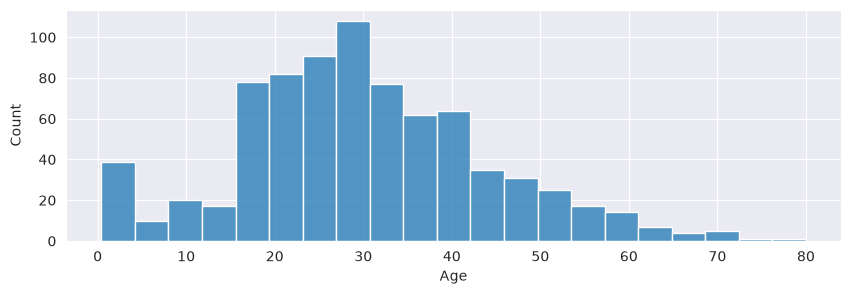

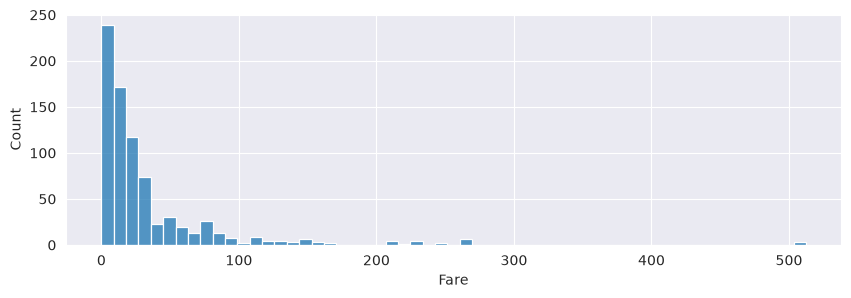

In [73]:
df5 = df4.copy()
for col in num_cols:
    plt.figure(figsize=(10,3))
    sns.histplot(data=df5, x =col)
    plt.show()

In [80]:
x = df5[['Fare']]
x_new = np.log(x+1) ## esto esta bien cuando no tengo valores 0. Ya que los valores muy altos se reducen mucho mientra sque los valores bajos se quedan mas o menos donde estan. si le sumamos 1, tmpc cambia excesivamente
# todos los que son valores 0 con np.log(x) no me los ploteaba porq serian nans, entonces hay q tener cuidado con esto. Como tenemos los valores 0, sumamos 1 para q me los muestre al menos. SI tuviesemos numeros negativos, tendiramos q desplazar todos los varlores a la derecha


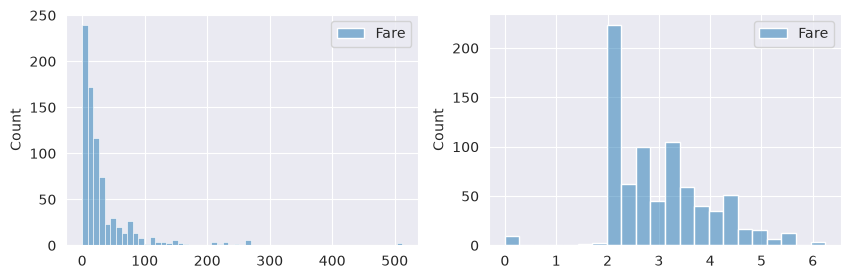

In [ ]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
sns.histplot(x)
plt.subplot(1,2,2)
sns.histplot(x_new) ## evidentemente este es bastante mejor solo q los valores pequeñitos aprecen q estan lejos pero realmente no estan tan lejos ya que cuando ahcemos calculos con los algoritmos dejan de estar tan lejos. ahroa estan redistribuidos mejor los datos
plt.show()

# con age quedaria hasta peor, me gusta mas el original

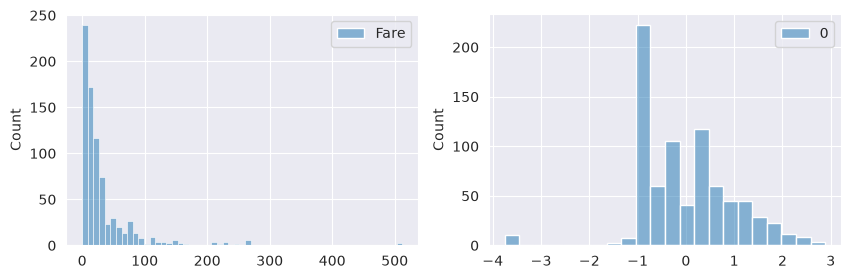

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
# vemos ahroa con box-cox
# pt =  PowerTransformer(method='box-cox') ## solo se puede hacer con datos positivos

x = df5[['Fare']]
x_new = pt.fit_transform(x)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
sns.histplot(x)
plt.subplot(1,2,2)
sns.histplot(x_new)
plt.show()

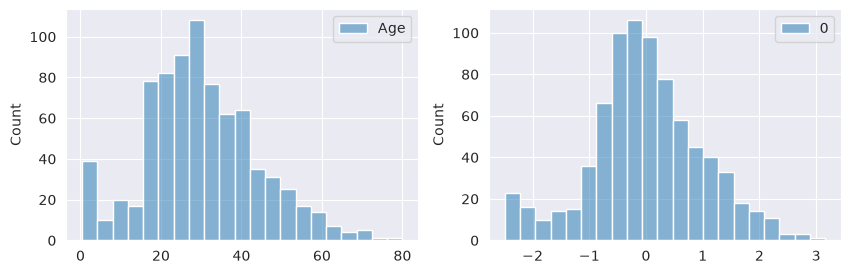

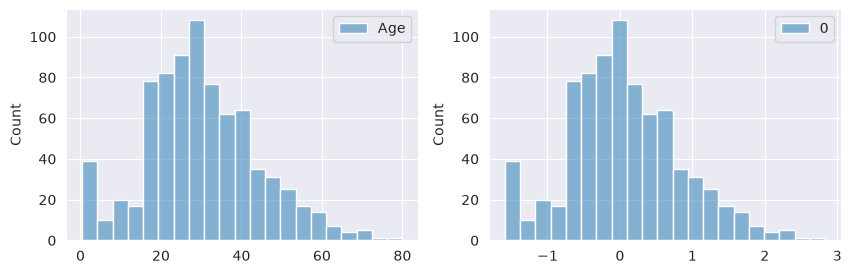

In [ ]:
from sklearn.preprocessing import PowerTransformer, RobustScaler

# pt = PowerTransformer(method='yeo-johnson')
# vemos ahroa con box-cox
pt =  PowerTransformer(method='box-cox') ## solo se puede hacer con datos positivos

x = df5[['Age']]
x_new = pt.fit_transform(x)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
sns.histplot(x)
plt.subplot(1,2,2)
sns.histplot(x_new)
plt.show()
# con age vemos que nos queda mas o menos igual pero nos queda mejor como si nos hiciese un standard scaler

scaler = RobustScaler()
x = df5[['Age']]
x_new = scaler.fit_transform(x)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
sns.histplot(x)
plt.subplot(1,2,2)
sns.histplot(x_new)
plt.show()
## da el pego q es un standard scaler normal y correiente. con fares e mantendria la misma distancia pero alrededor del 0


## columns transformer
esto es mas o menos para transforamr todas las columnas q queramos con el metodo q queramos

In [88]:
df6 = df3.copy()

In [ ]:
from sklearn.compose import ColumnTransformer

ctransf = ColumnTransformer(
    [
        ("imputer",KNNImputer(n_neighbors=5,metric='nan_euclidean'),['Pclass','Age','Parch','Fare','SibSp']),
        ('ohe1',OneHotEncoder(drop='if_binary'), ['Sex']),
        ('ohe2',OneHotEncoder(drop='first'), ['Embarked']), 
        ('ohe3',OneHotEncoder(categories=titles, handle_unknown='ignore'), ['Title']),
    ],
    remainder='passthrough' # esto es para que pasan aquellas variables que no estoy transformando (en este caso hascabin) !!!!IMPORTANTE!!!!"
)# nombre q queramos darle, objeto (transofmracion q darle) y la lsita de columnas
ctransf

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer', ...), ('ohe1', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [98]:
ctransf.fit_transform(df6)

array([[ 3. , 22. ,  0. , ...,  0. ,  0. ,  0. ],
       [ 1. , 38. ,  0. , ...,  0. ,  1. ,  1. ],
       [ 3. , 26. ,  0. , ...,  1. ,  1. ,  0. ],
       ...,
       [ 3. , 26.8,  2. , ...,  1. ,  0. ,  0. ],
       [ 1. , 26. ,  0. , ...,  0. ,  1. ,  1. ],
       [ 3. , 32. ,  0. , ...,  0. ,  0. ,  0. ]], shape=(788, 13))

In [99]:
ctransf.get_feature_names_out()

array(['imputer__Pclass', 'imputer__Age', 'imputer__Parch',
       'imputer__Fare', 'imputer__SibSp', 'ohe1__Sex_male',
       'ohe2__Embarked_Q', 'ohe2__Embarked_S', 'ohe3__Title_Mr',
       'ohe3__Title_Mrs', 'ohe3__Title_Miss', 'remainder__Survived',
       'remainder__hasCabin'], dtype=object)

In [100]:
df6.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Title', 'hasCabin'],
      dtype='str')

In [ ]:
# ejercicio
# train-test, knn-imputer, ohecats, lr

In [ ]:
x = df3[num_cols + cat_cols]
y = df3['Survived']
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, make_pipeline
seed = 99
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2,random_state=seed)

alg = LogisticRegression(random_state=seed)
ctransf = ColumnTransformer(
    [
        ("imputer",KNNImputer(n_neighbors=5,metric='nan_euclidean'),['Pclass','Age','Parch','Fare','SibSp']),
        # ('scaler',PowerTransformer(),num_cols)
        ('ohe1',OneHotEncoder(drop='if_binary'), ['Sex']),
        ('ohe2',OneHotEncoder(drop='first'), ['Embarked']), 
        ('ohe3',OneHotEncoder(categories=titles, handle_unknown='ignore'), ['Title']),
    ],
    remainder='passthrough' # esto es para que pasan aquellas variables que no estoy transformando (en este caso hascabin) !!!!IMPORTANTE!!!!"
)


x_transf = ctransf.fit_transform(x_train)

model = make_pipeline(ctransf,alg)
model.fit(x_train, y_train)
y_hat = model.predict(x_test)
accuracy_score(y_true=y_test, y_pred=y_hat)
# finalmente lo merjo es probar probar y probar con distintas formas


0.7974683544303798

In [115]:
model.steps

[('columntransformer',
  ColumnTransformer(remainder='passthrough',
                    transformers=[('imputer', KNNImputer(),
                                   ['Pclass', 'Age', 'Parch', 'Fare', 'SibSp']),
                                  ('ohe1', OneHotEncoder(drop='if_binary'),
                                   ['Sex']),
                                  ('ohe2', OneHotEncoder(drop='first'),
                                   ['Embarked']),
                                  ('ohe3',
                                   OneHotEncoder(categories=[['Mr', 'Mrs',
                                                              'Miss']],
                                                 handle_unknown='ignore'),
                                   ['Title'])])),
 ('logisticregression', LogisticRegression(random_state=99))]

In [ ]:
from sklearn.metrics import precision_score, recall_score
print(precision_score(y_true=y_test, y_pred = y_hat))
print(recall_score(y_true=y_test, y_pred = y_hat))
## casualmente la cm ha salido simetrica

0.7419354838709677
0.7419354838709677
